In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"humerag37python","key":"6f68c794d0ae0f63ca9cb49122ce8044"}'}

In [ ]:
!mv "kaggle (1).json" kaggle.json

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset
!unzip wildfire-prediction-dataset.zip -d wildfire_data

Streaming output truncated to the last 5000 lines.
  inflating: wildfire_data/valid/nowildfire/-73.465183,45.443641.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.465388,45.584881.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.469451,45.480331.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.471252,45.51974.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.472693,45.427766.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.473015,45.435254.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.475051,45.56612.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.477079,45.597274.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.478813,45.555686.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.479478,45.524618.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.480135,45.528248.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.480722,45.518864.jpg  
  inflating: wildfire_data/valid/nowildfire/-73.481149,45.563113.jpg  
  inflating: wildfire_data/v

In [ ]:
!ls

kaggle.json  sample_data  wildfire_data  wildfire-prediction-dataset.zip


In [ ]:
!ls wildfire_data

test  train  valid


In [ ]:
!ls -R

Streaming output truncated to the last 5000 lines.
-70.33478,46.21613.jpg	  -73.61218,46.11661.jpg    -77.21011,50.86031.jpg
-70.3359,48.4194.jpg	  -73.61325,46.34233.jpg    -77.21199,46.66936.jpg
-70.3361,47.0961.jpg	  -73.6134,46.19005.jpg     -77.21206,51.95174.jpg
-70.3367,49.4634.jpg	  -73.61345,46.14628.jpg    -77.21273,47.49581.jpg
-70.3369,47.4689.jpg	  -73.6162,51.41517.jpg     -77.21341,48.42566.jpg
-70.33733,48.89539.jpg	  -73.6174,45.4014.jpg	    -77.21386,51.52428.jpg
-70.3374,49.70624.jpg	  -73.61809,48.19904.jpg    -77.214296,45.966227.jpg
-70.33831,49.13999.jpg	  -73.6186,46.18735.jpg     -77.2145,49.5263.jpg
-70.33938,48.45264.jpg	  -73.61867,46.10672.jpg    -77.2158,50.87021.jpg
-70.34018,49.70893.jpg	  -73.61895,45.78327.jpg    -77.21711,48.98861.jpg
-70.34114,48.17836.jpg	  -73.61948,45.15258.jpg    -77.21729,46.57374.jpg
-70.34142,47.98591.jpg	  -73.62124,46.13999.jpg    -77.2175,48.4214.jpg
-70.34182,47.71163.jpg	  -73.62127,46.10402.jpg    -77.2183,47.0693.jpg
-7

In [ ]:
import os

train_path = "/content/wildfire_data/train"

classes = os.listdir(train_path)
print(classes)

['wildfire', 'nowildfire']


In [ ]:
from collections import Counter

counts = {}

for cls in classes:
    counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

print(counts)

{'wildfire': 15750, 'nowildfire': 14500}


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = torchvision.datasets.ImageFolder(
    root="/content/wildfire_data/train",
    transform=transform
)

val_dataset = torchvision.datasets.ImageFolder(
    root="/content/wildfire_data/valid",
    transform=transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root="/content/wildfire_data/test",
    transform=transform
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1.0431, 0.9603])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = torchvision.models.resnet18(pretrained=True)

# Modify final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.14271912939726408
Epoch 2, Loss: 0.08998874511991098
Epoch 3, Loss: 0.06752221124213736
Epoch 4, Loss: 0.058059355207368435
Epoch 5, Loss: 0.05023649090444585


In [ ]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2820
           1       0.99      0.98      0.99      3480

    accuracy                           0.99      6300
   macro avg       0.99      0.99      0.99      6300
weighted avg       0.99      0.99      0.99      6300



In [ ]:
class CNN_1x1(nn.Module):
    def __init__(self):
        super(CNN_1x1, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=1)
        self.pool = nn.MaxPool2d(2,2)

        # Temporary layer — will initialize later
        self.fc1 = None
        self.fc2 = None

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        # Initialize FC layers dynamically
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.shape[1], 128).to(x.device)
            self.fc2 = nn.Linear(128, 2).to(x.device)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
class CNN_2x2(nn.Module):
    def __init__(self):
        super(CNN_2x2, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=2)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = None
        self.fc2 = None

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        if self.fc1 is None:
            self.fc1 = nn.Linear(x.shape[1], 128).to(x.device)
            self.fc2 = nn.Linear(128, 2).to(x.device)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
def train_model(model, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

    return model

In [ ]:
def evaluate_model(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print("Accuracy:", acc)
    print(classification_report(all_labels, all_preds))

    return acc

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
acc1 = evaluate_model(model_1x1)

Accuracy: 0.871904761904762
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      2820
           1       0.88      0.89      0.88      3480

    accuracy                           0.87      6300
   macro avg       0.87      0.87      0.87      6300
weighted avg       0.87      0.87      0.87      6300



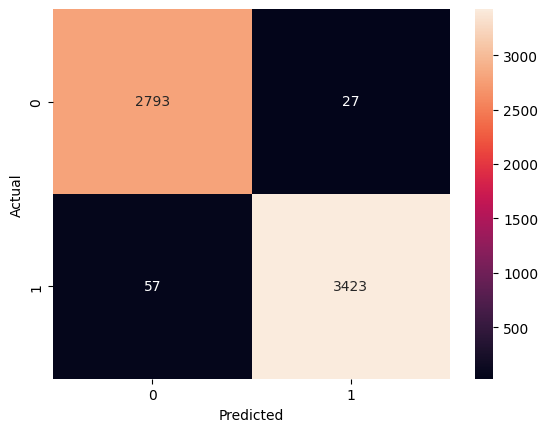

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model_1x1 = CNN_1x1()
model_1x1 = train_model(model_1x1, epochs=5)
acc1 = evaluate_model(model_1x1)

Epoch 1, Loss: 0.5688936967111289
Epoch 2, Loss: 0.37580778994784547
Epoch 3, Loss: 0.33478700231768616
Epoch 4, Loss: 0.3240712192972795
Epoch 5, Loss: 0.3187076890679671
Accuracy: 0.8960317460317461
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      2820
           1       0.89      0.92      0.91      3480

    accuracy                           0.90      6300
   macro avg       0.90      0.89      0.89      6300
weighted avg       0.90      0.90      0.90      6300



In [ ]:
model_2x2 = CNN_2x2()
model_2x2 = train_model(model_2x2, epochs=5)
acc2 = evaluate_model(model_2x2)

Epoch 1, Loss: 0.4131495405705232
Epoch 2, Loss: 0.30227131077559
Epoch 3, Loss: 0.2872142731103786
Epoch 4, Loss: 0.2778982748897711
Epoch 5, Loss: 0.2703079421931669
Accuracy: 0.9088888888888889
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      2820
           1       0.93      0.91      0.92      3480

    accuracy                           0.91      6300
   macro avg       0.91      0.91      0.91      6300
weighted avg       0.91      0.91      0.91      6300



In [ ]:
print("Accuracy 1x1 CNN:", acc1)
print("Accuracy 2x2 CNN:", acc2)

Accuracy 1x1 CNN: 0.8960317460317461
Accuracy 2x2 CNN: 0.9088888888888889


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "/content/wildfire_data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/wildfire_data/valid",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    "/content/wildfire_data/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 30250 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.043103448275862), 1: np.float64(0.9603174603174603)}


In [ ]:
def create_model_maxpool():
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def create_model_globalavg():
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model_max = create_model_maxpool()

history_max = model_max.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


946/946 ━━━━━━━━━━━━━━━━━━━━ 66s 64ms/step - accuracy: 0.8727 - loss: 0.2815 - val_accuracy: 0.9529 - val_loss: 0.1324
Epoch 2/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9403 - loss: 0.1644 - val_accuracy: 0.9541 - val_loss: 0.1359
Epoch 3/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9486 - loss: 0.1381 - val_accuracy: 0.9617 - val_loss: 0.1058
Epoch 4/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9511 - loss: 0.1307 - val_accuracy: 0.9600 - val_loss: 0.1142
Epoch 5/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.9614 - loss: 0.1087 - val_accuracy: 0.9662 - val_loss: 0.1001


In [ ]:
model_gap = create_model_globalavg()

history_gap = model_gap.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights
)

Epoch 1/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - accuracy: 0.8576 - loss: 0.2994 - val_accuracy: 0.9440 - val_loss: 0.1619
Epoch 2/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 61s 64ms/step - accuracy: 0.9288 - loss: 0.1909 - val_accuracy: 0.9490 - val_loss: 0.1409
Epoch 3/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9379 - loss: 0.1689 - val_accuracy: 0.9548 - val_loss: 0.1217
Epoch 4/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 59s 62ms/step - accuracy: 0.9431 - loss: 0.1489 - val_accuracy: 0.9510 - val_loss: 0.1255
Epoch 5/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9475 - loss: 0.1420 - val_accuracy: 0.9602 - val_loss: 0.1067


In [ ]:
max_loss, max_acc = model_max.evaluate(test_generator)
gap_loss, gap_acc = model_gap.evaluate(test_generator)

print("MaxPooling Accuracy:", max_acc)
print("GlobalAvgPooling Accuracy:", gap_acc)

197/197 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9729 - loss: 0.0729
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9646 - loss: 0.0846
MaxPooling Accuracy: 0.971746027469635
GlobalAvgPooling Accuracy: 0.9658730030059814


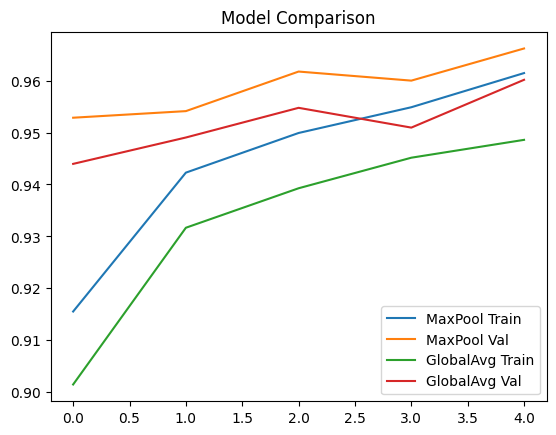

In [ ]:
plt.figure()
plt.plot(history_max.history['accuracy'], label='MaxPool Train')
plt.plot(history_max.history['val_accuracy'], label='MaxPool Val')

plt.plot(history_gap.history['accuracy'], label='GlobalAvg Train')
plt.plot(history_gap.history['val_accuracy'], label='GlobalAvg Val')

plt.legend()
plt.title("Model Comparison")
plt.show()